# RBP motif extraction and visualization

BRIDGE aims to extract motifs from RBP datasets and generate visualization graphics. BRIDGE uses a series of scripts and tools to achieve this, including FASTA file processing, sequence-structure Position Weight Matrix (PWM) generation, motif stability analysis, and final motif logo visualization.

## Overview of step-by-step instructions
```text
├── discover_motif.sh   # Discover motifs from attention maps
├── convert_format.py   # Convert .txt files to MEME format files
├── tomtom.py           # Compare motifs to mCrossBase database motifs using Tomtom
├── struct_motif.py     # Automatically extract motif-related sequences
├── seq_struct2pwm.py   # Generate combined sequence-structure PWM matrices
├── plot_motif_logo.R   # Read motif PWM matrices, calculate entropy, and plot motif logos
├── circos_motif.R     # Generate a circular heatmap with hierarchical clustering and motif visualization
```

## Prerequisites
  
1. Ensure all required R packages and Python libraries are installed.
2. Modify file paths and file names in the scripts to match your specific dataset.

## Dependencies

### R Packages

- dendsort
- dendextend
- circlize
- ComplexHeatmap
- grid
- ggplot2
- ggseqlogo
- ggsci
- gridExtra
- seqLogo
- Cairo

### Python Libraries

- argparse
- pathlib
- numpy
- Bio (Biopython)

## Input

- **Large-scale dataset inputs** (Figshare; one folder per dataset/RBP×cell):
  - `motif_construction/datasets/<DATASET_ID>/dev.tsv` (sequences used for motif mining)
  - `motif_construction/datasets/<DATASET_ID>/atten.npy` (per-position attention scores)
  - `motif_construction/datasets/<DATASET_ID>/pred_results.npy` (per-sequence prediction scores)

- **BRIDGE-discovered motif instances** (produced by `discover_motif.sh`):
  - `motif_construction/datasets/<RBP>_<CELL>/result/motif_<SEQ>_<INDEX>.txt`

- **Structural annotations** (Figshare; used to align structure to each discovered motif):
  - `utils/motif_prior/output/<RBP>_<CELL>/output/fg_alphabet_annotations.tab`

- **Motif databases for Tomtom** (Local):
  - `motif_construction/db/ATtRACT/<RBP>.meme`
  - `motif_construction/db/mCrossBase/<CELL>.<RBP>.meme`


## Output

- **Sequence motifs**
  - `motif_construction/datasets/<RBP>_<CELL>/result/*.txt` (motif instances)
  - `motif_construction/datasets/<RBP>_<CELL>/result/*.meme` (MEME format; produced by `convert_format.py`)

- **Tomtom similarity reports**
  - `motif_construction/datasets/<RBP>_<CELL>_tmp_results*/<meme_file>_tomtom_results/`

- **Combined sequence-structure PWMs (11×N)**
  - `motif_construction/datasets/Seq_struct_motif/<RBP>_<CELL>.txt`

- **Motif logo figures**
  - `motif_construction/datasets/Seq_struct_motif_logos/*.pdf`

- **Motif circos figures**
  - `circos_plot.png`


```{important}
The steps below support large-scale dataset analysis. Here we use two datasets as examples; for the remaining datasets, please download them from Figshare first and place them under the corresponding directories.
```

## Load attentions for motif discovery
### Download & prepare paper-scale inputs (Figshare)

To reproduce the paper-scale motif extraction **without re-running the model**, you need **two Figshare archives**:

1) **Datasets archive**
- Contains the *raw sequence sets* for each **RBP×cell** dataset (e.g., `pos.fa` / `neg.fa`).
- These sequences define **what biological instances we are mining motifs from**.

2) **Attention archive**
- Contains **precomputed model outputs** for each dataset:
  - `atten.npy`: per-sequence, per-position **attention scores**
  - `pred_results.npy`: per-sequence **probability of positive class**
- These files are the **direct inputs** to downstream motif discovery (so you can run motif extraction via `np.load(...)`).

#### Where to place them

Download both archives from Figshare and extract them into:

`motif_construction/datasets/`

After extraction, the expected layout is:
```
motif_construction/datasets/
  `<DATASET_ID>/`
    `dev.tsv`
    `atten.npy`
    `pred_results.npy`
```
- `<DATASET_ID>` is the dataset key (e.g., `AARS_K562`).
- Downstream scripts/notebooks will iterate over `datasets/*/` and load:
  - sequences from `dev.tsv`
  - attention outputs from `atten.npy` and `pred_results.npy`

In [ ]:
%%bash
set -euo pipefail

Motif_Construction_ROOT=$(cd "$(dirname "$0")/../../../../motif_construction"; pwd)
export KMER=1
echo $(pwd)
export LD_LIBRARY_PATH="$CONDA_PREFIX/lib:$LD_LIBRARY_PATH"
cd $Motif_Construction_ROOT

# Define the base directory
export BASE_DIR="datasets/"

# Loop through each folder in the BASE_DIR
for filename in $BASE_DIR*/; do
    if [ -d "$filename" ]; then
        echo "Processing folder: $filename"

        # Set the paths for the current folder
        export DATA_PATH=$filename
        export ATTENTION_PATH=$filename
        export OUTPUT_PATH=$filename/result/
        # Create the motif result directory if it doesn't exist
        mkdir -p $OUTPUT_PATH

        # Run the motif finding script for the current folder
        python motif/Discovery_motifs.py \
            --input_rna_dir $DATA_PATH \
            --attention_dir $ATTENTION_PATH \
            --motif_length 6 \
            --min_region_len 6 \
            --fdr_cutoff 0.05 \
            --min_motif_count 1 \
            --align_all_ties \
            --output_motif_dir $OUTPUT_PATH \
            --verbose
    fi
done


/fs1/private/user/wangyubo/code/BRIDGE/docs/tutorials/notebooks/motif_analysis
Processing folder: datasets/AARS_K562/

=== Motif Analysis ===
 * Positives: 1000
 * Negatives: 2000
 * Raw motifs found: 1201
 * Applying statistical filtering …
[+] Motif AGGGGG: N=3000; K=1000; n=114; x=66; p=3.60e-08
[+] Motif AGGAAA: N=3000; K=1000; n=135; x=72; p=7.73e-07
[+] Motif TGAAGA: N=3000; K=1000; n=243; x=116; p=8.53e-07
[+] Motif AAAAGA: N=3000; K=1000; n=117; x=66; p=1.44e-07
 * Motif sequences saved to → datasets/AARS_K562//result/

>>> Final motifs (top): ['AGGGGG', 'TGGGGA', 'CAAAAC', 'AGGAAA', 'TGAAGA', 'AAAAGA', 'GAGGATGAA', 'CCCAAGGACT']
Processing folder: datasets/AATF_K562/

=== Motif Analysis ===
 * Positives: 1000
 * Negatives: 2000
 * Raw motifs found: 1202
 * Applying statistical filtering …
[+] Motif GGGCGGG: N=3000; K=1000; n=56; x=35; p=6.16e-06
[+] Motif TGCGGC: N=3000; K=1000; n=130; x=67; p=9.12e-06
[+] Motif GGGGGC: N=3000; K=1000; n=184; x=99; p=2.92e-09
[+] Motif CGGGTT:

## Convert .txt files under 'result' directories to MEME format files.

In [ ]:
import os
import numpy as np

alphabet = ['A', 'C', 'G', 'U']
letter_to_idx = {letter: idx for idx, letter in enumerate(alphabet)}

def txt_to_meme(input_path, output_path):
    '''
    Convert a.txt file to a MEME format file.
    :param input_path: Path to the input.txt file.
    :param output_path: Path to the output.meme file.
    '''
    with open(input_path, 'r') as file:
        sequences = [line.strip().replace('T', 'U') for line in file.readlines()]

    # Initialise a matrix to store the probability for each position.
    num_sequences = len(sequences)
    sequence_length = len(sequences[0])
    probability_matrix = np.zeros((sequence_length, len(alphabet)))

    # Compute the probability matrix.
    for seq in sequences:
        for i, base in enumerate(seq):
            probability_matrix[i][letter_to_idx[base]] += 1

    # Convert the frequency to probability (probability of each position is the number of times the base appears / total number of sequences).
    probability_matrix /= num_sequences

    # Write the probability matrix to a MEME file.
    with open(output_path, 'w') as f:
        # MEME file header
        f.write("MEME version 5\n")
        f.write("ALPHABET= ACGU\n")
        f.write("Background letter frequencies: A 0.25 C 0.25 G 0.25 U 0.25\n")
        motif_name = os.path.basename(input_path).replace('.txt', '')  # Use the file name as the MOTIF name.
        f.write(f"MOTIF {motif_name}\n")
        f.write(f"letter-probability matrix: alength= 4 w= {sequence_length}\n")
        
        # Write the probability matrix.
        for i in range(sequence_length):
            f.write(" ".join([f"{prob:.14f}" for prob in probability_matrix[i]]) + "\n")

    print(f"Meme file written to {output_path}")

def process_directory(base_directory):
    # Process all directories under the base directory.
    for root, dirs, files in os.walk(base_directory):
        if 'result' in root:  # Only process directories containing 'result'.
            for file in files:
                if file.endswith('.txt'):  # Only process .txt files.
                    input_file = os.path.join(root, file)
                    output_file = os.path.join(root, file.replace('.txt', '.meme'))  # Output as .meme file.
                    txt_to_meme(input_file, output_file)

# Main program, set the base directory to be processed.
base_directory = "../../../../motif_construction/datasets"
process_directory(base_directory)


Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_AGGAAA_1.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_GAGGATGAA_1.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_CCCAAGGACT_1.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_AGGGGG_1.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_TGAAGA_2.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_TGGGGA_4.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_CAAAAC_1.meme
Meme file written to ../../../../motif_construction/datasets/AARS_K562/result/motif_AAAAGA_1.meme
Meme file written to ../../../../motif_construction/datasets/AATF_K562/result/motif_CGGCCC_3.meme
Meme file written to ../../../../motif_construction/datasets/AATF_K562/result/motif_GCGTGG_9.meme
Meme file wri

## Run Tomtom to compare discovered motifs (MEME) against mCrossBase and ATtRACT

This section runs **Tomtom** (from the MEME suite) to **match BRIDGE-discovered motifs** against two external motif databases:
- **ATtRACT** (RBP motif collection)
- **mCrossBase** (cell/RBP-specific motif collection)

The goal is to produce **per-motif similarity reports** (Tomtom outputs) that can later be used for:
- validating that discovered motifs resemble known motifs,
- finding database “hits” for each discovered motif,
- enabling downstream *intersection / selection* logic for paper figures.

### What this script does

For each **database** × **RBP** × **cell line**:
1) Look for BRIDGE motif results in:
   `motif_construction/datasets/<RBP>_<CELL>/result/*.meme`
2) For every discovered motif file `*.meme`, run:
   `tomtom <DB_MOTIF_FILE> <DISCOVERED_MOTIF_FILE>`
3) Save Tomtom outputs to a dedicated folder:
   `motif_construction/datasets/<RBP>_<CELL>_<tmp_suffix>/<meme_file>_tomtom_results/`

### Prerequisites

Install Tomtom (MEME suite)

You need the `tomtom` executable available in your PATH:

`conda install -c conda-forge -c bioconda meme`

Verify:
`tomtom -h`

### Inputs

#### A) BRIDGE discovered motif files (query motifs)
For each dataset:
`motif_construction/datasets/<RBP>_<CELL>/result/*.meme`

Each `*.meme` file is a set of motifs discovered by BRIDGE and written in **MEME motif format**.

#### B) Database motif files (target motifs)
Depending on the database:
- ATtRACT: `motif_construction/db/ATtRACT/<RBP>.meme`
- mCrossBase: `motif_construction/db/mCrossBase/<CELL>.<RBP>.meme`

### Outputs

For each dataset and each query MEME file, Tomtom writes a result directory:

ATtRACT example:
`motif_construction/datasets/HNRNPU_K562_tmp_results/<query_file>.meme_tomtom_results/`

mCrossBase example:
`motif_construction/datasets/HNRNPU_K562_tmp_results_mcross/<query_file>.meme_tomtom_results/`

Tomtom typically generates files like:
- `tomtom.tsv` (main match table)
- `tomtom.xml`
- `tomtom.html`
- PNG motif alignment images

In [ ]:
import os
import subprocess
from pathlib import Path

# List of cell lines
cell_lines = ['K562', 'HepG2', 'HEK293', 'H9', 'HEK293T', 'HeLa']

# Base directory containing example results
BRIDGE_HOME = Path.cwd().resolve().parents[3]
BRIDGE_HOME = str(BRIDGE_HOME) + "/"
base_directory = os.path.join(BRIDGE_HOME,'motif_construction/datasets')
# Directory containing input FASTA files (used to derive RBP names)

# Database configurations: ATtRACT and mCrossBase. You need to download these sources from our Figshare page.
databases = {
    'ATtRACT': {
        'path': BRIDGE_HOME +'motif_construction/db/ATtRACT',
        'tmp_suffix': '_tmp_results',
        'min_overlap': '5',
        'db_file_pattern': '{rbp}.meme'
    },
    'mCrossBase': {
        'path': BRIDGE_HOME +'motif_construction/db/mCrossBase',
        'tmp_suffix': '_tmp_results_mcross',
        'min_overlap': '6',
        'db_file_pattern': '{cell}.{rbp}.meme'
    }
}

# Get all RBP names
rbp_files = [d for d in os.listdir(base_directory) if os.path.isdir(os.path.join(base_directory, d)) and "_" in d]
rbps = set(f.split('_')[0] for f in rbp_files)

# Iterate over databases, RBPs, and cell lines
for db_name, db_conf in databases.items():
    meme_directory = db_conf['path']
    print(f"\n=== Running Tomtom for database: {db_name} ===")

    for rbp in rbps:
        for cell in cell_lines:
            # Construct the path to the result folder
            result_directory = os.path.join(base_directory, f"{rbp}_{cell}", "result")

            # Skip if the result folder does not exist
            if not os.path.exists(result_directory):
                # print(f"Skipping {rbp}_{cell}: result folder does not exist.")
                continue

            # Temporary directory for Tomtom intermediate results
            tmp_dir = os.path.join(base_directory, f"{rbp}_{cell}{db_conf['tmp_suffix']}")
            os.makedirs(tmp_dir, exist_ok=True)

            # Iterate through all MEME files in the result folder
            for file in os.listdir(result_directory):
                if not file.endswith('.meme'):
                    continue

                meme_file = os.path.join(result_directory, file)

                # Output directory for Tomtom results
                out_directory = os.path.join(tmp_dir, f"{file}_tomtom_results")
                os.makedirs(out_directory, exist_ok=True)

                # Determine the corresponding motif database file
                db_meme = db_conf['db_file_pattern'].format(rbp=rbp, cell=cell)
                db_meme_path = os.path.join(meme_directory, db_meme)

                # Skip if the database motif file is missing
                if not os.path.exists(db_meme_path):
                    print(f"Database file not found: {db_meme_path}, skipping...")
                    continue

                # Construct the Tomtom command
                tomtom_cmd = [
                    'tomtom', '-no-ssc', '-oc', out_directory,
                    '-verbosity', '1',
                    '-min-overlap', db_conf['min_overlap'],
                    '-dist', 'pearson', '-evalue', '-thresh', '0.05',
                    '-time', '300', '-png',
                    db_meme_path,
                    meme_file
                ]

                # Execute Tomtom
                print(f"Running Tomtom for {file} in {cell} ({db_name})...")
                subprocess.run(tomtom_cmd)



=== Running Tomtom for database: ATtRACT ===
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not found: /fs1/private/user/wangyubo/code/BRIDGE/motif_construction/db/ATtRACT/AATF.meme, skipping...
Database file not 

## Automatically extract motif-related structural features from multiple RBP-cell-specific result folders
It iterates through all subdirectories under the given base path, each representing one RBP-cell combination.
For every `.txt` motif file found in the `result/` folder, it performs the following steps:

1. Parse motif names and numeric indices from filenames (e.g., motif_TGCGGC_3.txt).
2. Apply filtering criteria:
   - The motif sequence (the middle part) must be exactly 6 letters long.
   - The final numeric suffix must be greater than 2 (optional, can be enabled).
3. Match each motif against the corresponding annotation files
   (`utils/motif_prior/output/{rbp_cell_folder}/output/fg_alphabet_annotations.tab`), which are saved in the figshare repository and contain the aligned structures for each motif.
4. Extract the aligned six-letter sequence from the same position as the motif match.
5. Write the extracted structures into separate FASTA files, ensuring that
   each motif has its own dedicated output folder to avoid overwriting.

Output files are saved in:
    `../../../../motif_construction/datasets/Struct_motifs/{RBP_CELL}/{MOTIF}_{INDEX}/`



In [ ]:
import re
import os

# Base directory containing subdirectories for each RBP_CELL
BRIDGE_ROOT="../../../../"
base_dir = BRIDGE_ROOT+'motif_construction/datasets/'
print(base_dir)
# Iterate through all subdirectories (each representing an RBP_CELL)
for rbp_cell_folder in os.listdir(base_dir):
    rbp_cell_path = os.path.join(base_dir, rbp_cell_folder)
    
    # Proceed only if it is a directory
    if os.path.isdir(rbp_cell_path):
        result_dir = os.path.join(rbp_cell_path, 'result')
        
        # Ensure the result directory exists
        if os.path.exists(result_dir):
            # Iterate through all .txt files inside the "result" directory
            for motif_file_name in os.listdir(result_dir):
                if motif_file_name.endswith('.txt'):
                    motif_file_path = os.path.join(result_dir, motif_file_name)
                    
                    # Extract motif sequence name (e.g., motif_TGGGAG_3.txt → TGGGAG)
                    motif_name_match = re.match(r'motif_([A-Z]+)_\d+\.txt', motif_file_name)
                    if motif_name_match:
                        motif_name = motif_name_match.group(1)
                        # Replace T with U to convert DNA to RNA format
                        motif_name = motif_name.replace('T', 'U')
                        
                        # Split the motif filename to extract numeric and sequence parts
                        motif_parts = motif_file_name.split('_')
                        last_num = int(motif_parts[-1].replace('.txt', ''))  # Last numeric part of the filename
                        
                        # This section filters motif files based on naming conventions
                        # Conditions:
                        #   (1) The last number must be > 2
                        #   (2) The motif sequence must be exactly 6 letters long
                        if len(motif_parts) >= 3:
                            try:
                                # Uncomment below if you want to strictly enforce last_num > 2
                                # if last_num <= 2:
                                #     continue
                                
                                if len(motif_name) != 6:
                                    continue  # Skip motifs that are not 6 letters long
                            except ValueError:
                                continue

                        # Construct path to the annotation file for this RBP_CELL
                        annotations_file = BRIDGE_ROOT+f'utils/motif_prior/output/{rbp_cell_folder}/output/fg_alphabet_annotations.tab'

                        # Proceed only if the annotation file exists
                        if os.path.exists(annotations_file):
                            with open(annotations_file, 'r') as annotations_file_obj:
                                annotations_lines = annotations_file_obj.readlines()

                            # Iterate through each line in the annotation file
                            for line in annotations_lines:
                                fields = line.strip().split('\t')
                                
                                # Skip malformed lines
                                if len(fields) < 2:
                                    continue

                                sequence = fields[1]      # Full RNA sequence
                                struct7  = fields[-1]     # 7-state structural alphabet aligned to `sequence` (E, L, H, R, B, M, T)

                                # Search for the motif sequence within the second field
                                match = re.search(motif_name, sequence)
                                if match:
                                    # Determine the position of the motif within the sequence
                                    position = match.start()
                                    
                                    # Aligned 6-char structure motif
                                    six_letters = struct7[position:position+6]
                                    
                                    # Create a FASTA header line
                                    fasta_header = f">{rbp_cell_folder}_motif_{motif_name}_pos_{position+1}"
                                    fasta_sequence = six_letters
                                    
                                    # Define output directory (unique per motif to avoid overwriting)
                                    output_dir = BRIDGE_ROOT+f"motif_construction/datasets/Struct_motifs/{rbp_cell_folder}/{motif_name}_{last_num}"
                                    os.makedirs(output_dir, exist_ok=True)
                                    
                                    # Define output FASTA file path
                                    output_fa_path = f"{output_dir}/{rbp_cell_folder}_{motif_name}_{last_num}.fa"
                                    
                                    # Append the FASTA entry to the output file
                                    with open(output_fa_path, 'a') as fa_file:
                                        fa_file.write(f"{fasta_header}\n{fasta_sequence}\n")
                            print(f"[Processed] {rbp_cell_folder}")
                        else:
                            print(f"Warning: Annotation file not found for {rbp_cell_folder}: {annotations_file}")
        else:
            print(f"Warning: Result directory not found for {rbp_cell_folder}")


../../../../motif_construction/datasets/
[Processed] AARS_K562
[Processed] AARS_K562
[Processed] AARS_K562
[Processed] AARS_K562
[Processed] AARS_K562
[Processed] AARS_K562


## Generate combined sequence-structure Position Weight Matrices (PWMs) for multiple RBP cell lines

For each RBP-cell combination directory under the base path, it:
- Searches for all FASTA files that contain RNA secondary structure motifs.
- Matches each structural motif with its corresponding sequence motif file (motif_*.txt).
- Converts the paired data into an 11*N PWM matrix, where:
   - The first 4 rows represent nucleotide frequencies (A, C, G, U).
   - The last 7 rows represent structural element frequencies (L, R, E, H, B, M, T).
   - N is the motif length (typically 6).
- Normalizes both parts and writes the resulting PWM matrix to an output file specific to each RBP-cell.

Output directory:

    `motif_construction/datasets/Seq_struct_motif/{RBP_CELL}.txt`


In [ ]:
import os
import numpy as np
from Bio import SeqIO


#  PWM Construction Functions
def seq_to_pwm(sequences, motif_len, structure_data):
    """
    Convert a list of RNA sequences and structural annotations into an 11*N PWM matrix.

    Parameters:
        sequences (list of str): List of RNA sequences (ACGU).
        motif_len (int): Length of the motif.
        structure_data (list of str): List of structural annotation strings (L, R, E, H, B, M, T).

    Returns:
        np.ndarray: PWM matrix with 11 rows (4 for ACGU + 7 for structure) and motif_len columns.
    """
    pwm = np.zeros((11, motif_len))  # 11 rows: 4 (ACGU) + 7 (structure)
    bases = ['A', 'C', 'G', 'T']     # Note: 'T' is used for compatibility with motif files
    structures = ['L', 'R', 'E', 'H', 'B', 'M', 'T']

    # Process sequence (ACGU) part
    for seq in sequences:
        for i, base in enumerate(seq):
            if base in bases:
                pwm[bases.index(base), i] += 1

    # Normalize nucleotide part
    pwm[:4, :] /= len(sequences)

    # Process structure part
    for struct in structure_data:
        for i, s in enumerate(struct):
            if s in structures:
                pwm[4 + structures.index(s), i] += 1

    # Normalize structure part
    pwm[4:, :] /= len(structure_data)

    return pwm


def save_pwm_to_file(pwm, output_file):
    """
    Save a PWM matrix to a text file.
    """
    np.savetxt(output_file, pwm, fmt='%.6f', delimiter="\t")


def process_fasta_and_motif(fasta_file, motif_file, output_file, motif_name):
    """
    Process one pair of FASTA and motif files to generate a PWM matrix.

    Parameters:
        fasta_file (str): Path to the FASTA file containing structural motifs.
        motif_file (str): Path to the motif file containing sequence motifs.
        output_file (str): File to save the resulting PWM matrix.
        motif_name (str): Name of the motif being processed.
    """
    # Load structure strings from the FASTA file
    structures = [str(record.seq) for record in SeqIO.parse(fasta_file, "fasta")]

    # Load sequences from the motif file
    with open(motif_file, 'r') as f:
        sequences = [line.strip() for line in f.readlines()]

    # Assume all motifs have the same length
    motif_len = len(sequences[0])

    # Generate PWM
    pwm = seq_to_pwm(sequences, motif_len, structures)

    # Write PWM matrix to the output file
    with open(output_file, 'a') as out_f:
        out_f.write(f"{motif_name}\n")
        np.savetxt(out_f, pwm, fmt='%.6f', delimiter="\t")
        out_f.write('\n')


def find_and_process_files(base_dir, result_dir, output_file):
    """
    Search for all FASTA files in the given directory and process each one
    along with its corresponding motif file to produce PWM matrices.

    Parameters:
        base_dir (str): Directory containing structural FASTA files.
        result_dir (str): Directory containing sequence motif files.
        output_file (str): Output file for the combined PWM results.
    """
    for root, _, files in os.walk(base_dir):
        fasta_files = [f for f in files if f.endswith(".fa")]

        for fasta_file in fasta_files:
            # Extract motif name from the FASTA filename, e.g., AARS_K562_CAAAAC_1.fa
            motif_name = os.path.basename(fasta_file).split('.')[0]
            motif = motif_name.split('_')[2] + '_' + motif_name.split('_')[3]
            motif = motif.replace('U', 'T')  # Ensure compatibility with motif file names

            motif_file = os.path.join(result_dir, f"motif_{motif}.txt")

            # Only process if the motif file exists
            if os.path.exists(motif_file):
                fasta_file_path = os.path.join(root, fasta_file)
                process_fasta_and_motif(fasta_file_path, motif_file, output_file, motif_name)


def process_rbp_cells(base_parent_dir, result_parent_dir, output_parent_dir):
    """
    Automatically detect all RBP-cell directories under the base parent directory
    and generate PWM matrices for each one.

    Parameters:
        base_parent_dir (str): Base directory containing subdirectories for each RBP-cell.
        result_parent_dir (str): Parent directory containing motif result folders.
        output_parent_dir (str): Directory where output files will be stored.
    """
    # Automatically get all RBP-cell folders
    rbp_cells = [
        d for d in os.listdir(result_parent_dir)
        if os.path.isdir(os.path.join(result_parent_dir, d))
    ]

    for rbp_cell in rbp_cells:
        base_dir = os.path.join(base_parent_dir, rbp_cell)
        result_dir = os.path.join(result_parent_dir, rbp_cell, "result")
        os.makedirs(output_parent_dir, exist_ok=True)
        output_file = os.path.join(output_parent_dir, f"{rbp_cell}.txt")

        print(f"Processing {rbp_cell}...")

        # Remove existing output file to start fresh
        if os.path.exists(output_file):
            os.remove(output_file)

        find_and_process_files(base_dir, result_dir, output_file)

        print(f"PWM matrix generation completed for {rbp_cell}.")

#  Main Script Execution
BRIDGE_ROOT="../../../../"
base_parent_dir = BRIDGE_ROOT+"motif_construction/datasets/Struct_motifs"
result_parent_dir = BRIDGE_ROOT+"motif_construction/datasets"
output_parent_dir = BRIDGE_ROOT+"motif_construction/datasets/Seq_struct_motif"

# Start processing all detected RBP-cell directories
process_rbp_cells(base_parent_dir, result_parent_dir, output_parent_dir)

print("PWM matrix generation completed for all RBP-cell datasets.")


Processing AATF_K562_tmp_results...
PWM matrix generation completed for AATF_K562_tmp_results.
Processing Struct_motifs...
PWM matrix generation completed for Struct_motifs.
Processing AARS_K562_tmp_results...
PWM matrix generation completed for AARS_K562_tmp_results.
Processing AARS_K562...
PWM matrix generation completed for AARS_K562.
Processing AATF_K562_tmp_results_mcross...
PWM matrix generation completed for AATF_K562_tmp_results_mcross.
Processing AARS_K562_tmp_results_mcross...
PWM matrix generation completed for AARS_K562_tmp_results_mcross.
Processing AATF_K562...
PWM matrix generation completed for AATF_K562.
PWM matrix generation completed for all RBP-cell datasets.


## Sequence and structure motif plotting
This script is used to read motif PWM matrices (sequence + structure)
from input files, calculate the entropy of each motif to evaluate stability,
and visualize both sequence and structure logos. The motif with the lowest entropy is selected and
plotted as the most stable candidate.


[1] "AARS_K562.txt"


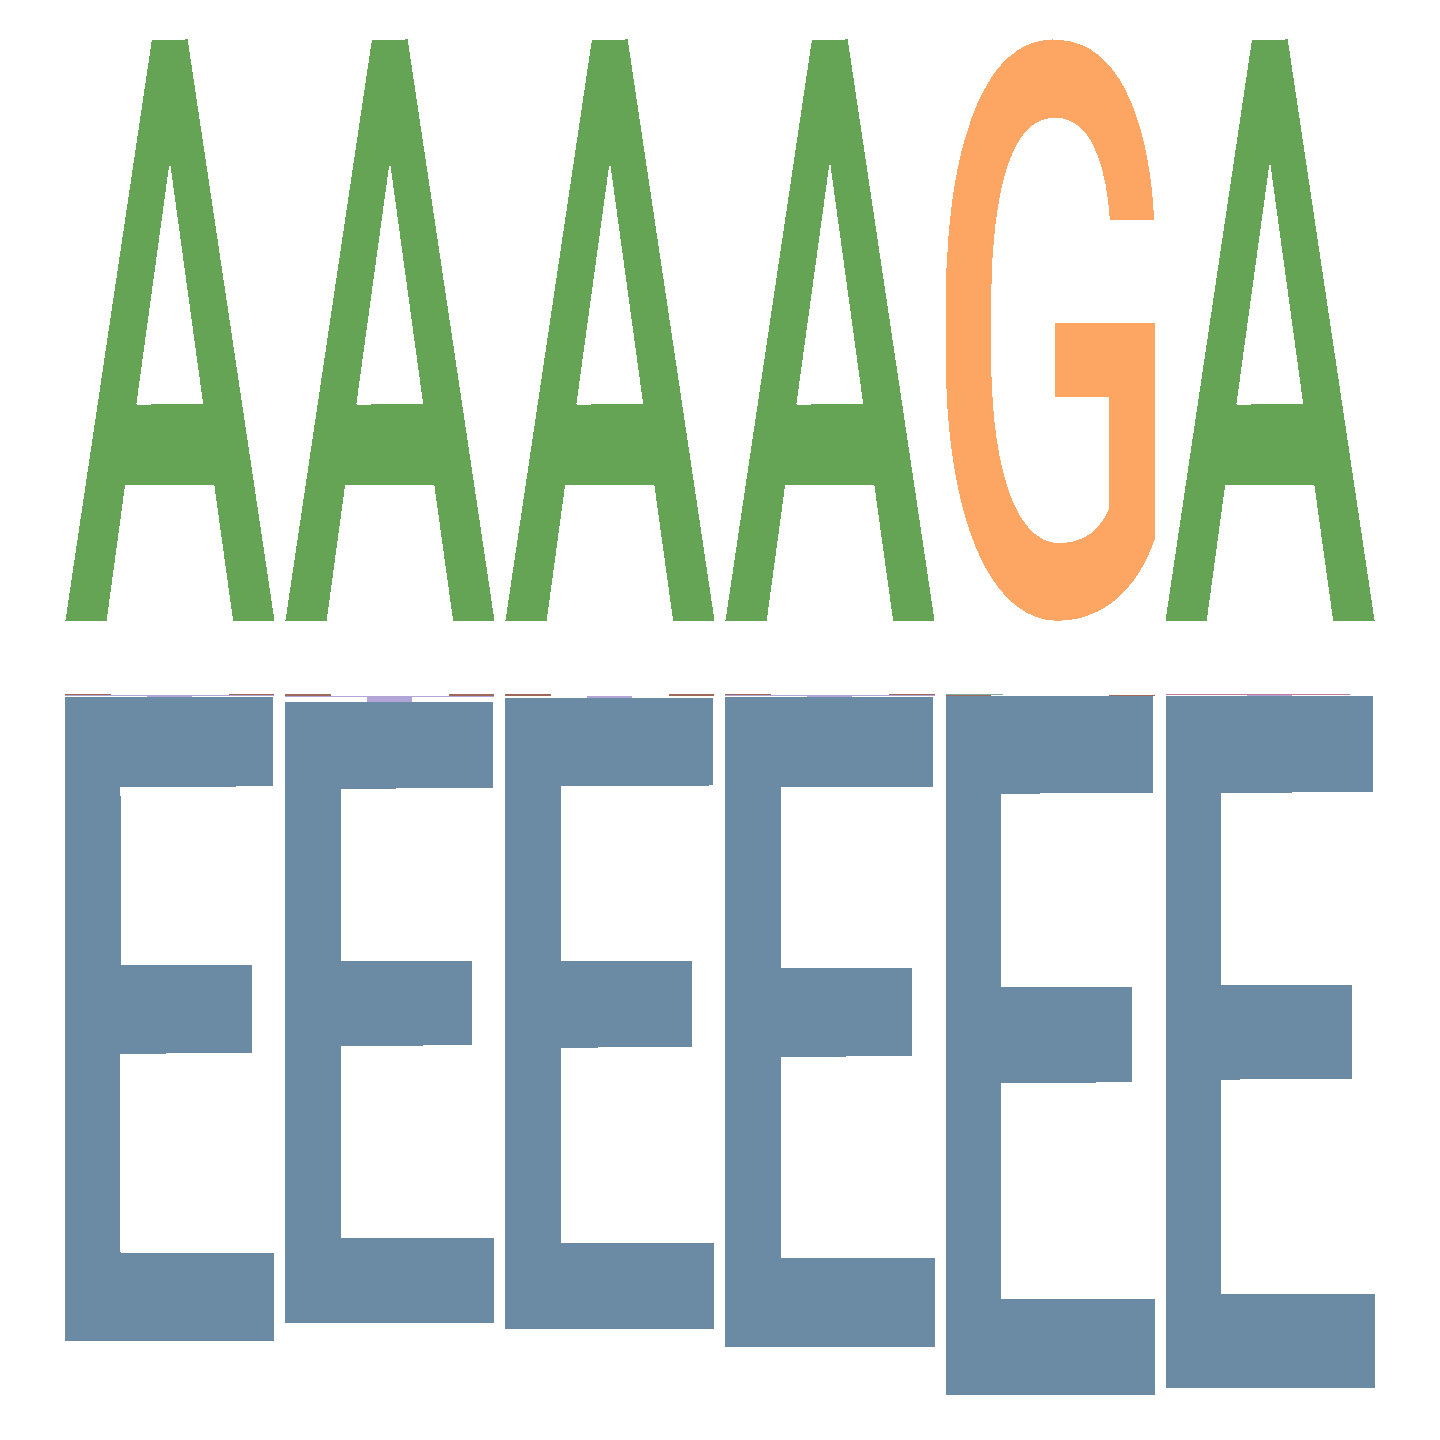

In [ ]:
library(ggseqlogo)
library(ggplot2)
library(gridExtra)
library(grid)
# library(seqLogo)
library(Cairo)

#------------------------------------------------------------
# Function: calculate_entropy
# Purpose: Compute total Shannon entropy across all positions
#          in a given PWM matrix. Lower entropy indicates a
#          more stable motif.
#------------------------------------------------------------
calculate_entropy <- function(pwm) {
  position_entropy <- apply(pwm, 2, function(col) {
    col[col > 0] * log2(col[col > 0])  # Compute only for non-zero probabilities
  })
  total_entropy <- -sum(unlist(position_entropy), na.rm = TRUE)
  return(total_entropy)
}

#------------------------------------------------------------
# Function: read_motifs
# Purpose: Read PWM matrices (sequence + structure) for each motif
#          from the given file. Each motif consists of 13 lines:
#          1 line for motif name + 11 lines for PWM + 1 blank line.
#------------------------------------------------------------
read_motifs <- function(file_path) {
  if (file.info(file_path)$size == 0) {
    return(NULL)
  }

  lines <- readLines(file_path)
  group_size <- 13
  motifs <- list()

  for (i in seq(1, length(lines), by = group_size)) {
    motif_name <- lines[i]
    pwm_matrix <- matrix(NA, nrow = 11, ncol = 6)
    for (j in 1:11) {
      pwm_matrix[j, ] <- as.numeric(strsplit(lines[i + j], "\\s+")[[1]])
    }
    motifs[[motif_name]] <- pwm_matrix
  }
  return(motifs)
}

#------------------------------------------------------------
# Function: adjusted_str_matrix_power
# Purpose: Apply a power transformation to the structure PWM matrix.
#          Steps:
#            1. Apply power (β)
#            2. Compute column-wise sum and convert to bits
#            3. Normalize each column and scale by its bit value
#------------------------------------------------------------
adjusted_str_matrix_power <- function(str, beta = 2) {
  adjusted_str <- matrix(0, nrow = nrow(str), ncol = ncol(str))

  for (col in seq_len(ncol(str))) {
    col_values <- str[, col]

    powered <- col_values^beta

    col_sum <- sum(powered)
    col_bits <- log2(col_sum)

    weights <- powered / col_sum
    adjusted_col <- weights * col_bits

    adjusted_str[, col] <- adjusted_col
  }

  return(abs(adjusted_str))
}

#------------------------------------------------------------
# Define input and output directories
#------------------------------------------------------------
Motif_Construction_ROOT="../../../../motif_construction"
motif_file_dir <- file.path(Motif_Construction_ROOT, "datasets/Seq_struct_motif/")
motif_fig_outdir <- file.path(Motif_Construction_ROOT, "datasets/Seq_struct_motif_logos/")

if (!file.exists(motif_fig_outdir)) {
  dir.create(motif_fig_outdir)
}

motif_files <- list.files(motif_file_dir)
print(motif_files)
#------------------------------------------------------------
# Main loop: Process each motif file
#------------------------------------------------------------
for (file in motif_files) {
  i <- 0
  file_path <- file.path(motif_file_dir, file)
  motif_list <- read_motifs(file_path)
  if (is.null(motif_list)) {
    next
  }

  # Compute entropy for each motif and sort by stability (lowest entropy)
  motif_entropies <- sapply(motif_list, calculate_entropy)
  sorted_entropies <- sort(motif_entropies)

  # Select the motif with the lowest entropy and visualize
  for (motif_name in names(sorted_entropies)) {
    pwm_matrix <- motif_list[[motif_name]]

    # Split into sequence and structure parts
    seq <- pwm_matrix[1:4, ]
    rownames(seq) <- c("A", "C", "G", "U")

    str <- pwm_matrix[5:11, ]
    rownames(str) <- c("L", "R", "E", "H", "B", "M", "T")
    
    # Apply power transformation to the structure matrix
    adjusted_height_matrix_str <- adjusted_str_matrix_power(str, beta = 6)
    rownames(adjusted_height_matrix_str) <- c("L", "R", "E", "H", "B", "M", "T")
    
    # Define color schemes
    custom_col_scheme_seq <- make_col_scheme(
      chars = c("A", "C", "G", "U"),
      groups = c("A", "C", "G", "U"),
      cols = c("#65a455", "#2e45a4", "#fda562", "#d54f3f")
    )

    custom_col_scheme_str <- make_col_scheme(
      chars = c("L", "R", "E", "H", "B", "M", "T"),
      groups = c("L", "R", "E", "H", "B", "M", "T"),
      cols = c(
        "#7daea3", "#c27ba0", "#6b8ba4",
        "#a1695b", "#a9b665", "#e0a96d", "#b1a5d8"
      )
    )

    # Flip the structure matrix vertically for visualization
    adjusted_height_matrix_str <- -adjusted_height_matrix_str

    # Create sequence and structure logo plots
    plot_seq <- ggseqlogo(seq, method = "bits", seq_type = "rna", col_scheme = custom_col_scheme_seq) +
      theme_void()

    plot_str <- ggseqlogo(adjusted_height_matrix_str, method = "custom", seq_type = "other",
      namespace = c("L", "R", "E", "H", "B", "M", "T"), col_scheme = custom_col_scheme_str) +
      theme_void()

    # Combine sequence and structure plots vertically
    p_combined <- arrangeGrob(
      plot_seq + theme(plot.margin = unit(c(0.22, 0, 0.1, 0), "cm")),
      plot_str + theme(plot.margin = unit(c(0.1, 0, 0.22, 0), "cm")),
      ncol = 1,
      heights = c(1, 1.2)
    )

    # Save motif logo as PDF
    pdf(file = paste(motif_fig_outdir, "/", motif_name, ".pdf", sep = ""), width = 2.3, height = 1.5, bg = "transparent")
    grid.draw(p_combined)
    dev.off()

    i <- i + 1
    if (i >= 1) {  # Plot only the most stable motif per file
      break
    }
  }
}

grid.draw(p_combined)


## Circos Plotting Script
After obtaining the RBP motifs for different cell lines through the above code, we next generate a circular heatmap integrating hierarchical clustering and motif visualization. 
It reads RBP motifs (both sequence and structural components), performs hierarchical clustering 
based on their flattened PWM matrices, and visualizes them as circular dendrograms with annotated RBP domains and 
motif logos around the circle using Circos-style graphics. The script highlights different RBP functional categories 
and structural domains in separate tracks.

```{note}
Generating `motif_construction/datasets/Seq_struct_motif/` and `motif_construction/datasets/Seq_struct_motif_logos/` folders is computationally expensive. To generate the Circos figure without repeating this full computation, we provide the precomputed outputs on **Figshare**. You need to download and put them in the correct location, or you can generate them yourself by running the above all notebooks.
```

Warning message in readLines(file.path(annot_dir, "splicerbp_list.txt")):
“incomplete final line found on '../../../../motif_construction/RBP_annotation_data/splicerbp_list.txt'”
Warning message in readLines(file.path(annot_dir, "stabilityrbp_list.txt")):
“incomplete final line found on '../../../../motif_construction/RBP_annotation_data/stabilityrbp_list.txt'”
Warning message in readLines(file.path(annot_dir, "translationrbp_list.txt")):
“incomplete final line found on '../../../../motif_construction/RBP_annotation_data/translationrbp_list.txt'”
Note: 2 points are out of plotting region in sector 'all', track '6'.

Note: 3 points are out of plotting region in sector 'all', track '6'.

Warning message in grid.Call.graphics(C_setviewport, vp, TRUE):
“cannot clip to rotated viewport”
Warning message in grid.Call.graphics(C_setviewport, vp, TRUE):
“cannot clip to rotated viewport”
Warning message in grid.Call.graphics(C_setviewport, vp, TRUE):
“cannot clip to rotated viewport”
Warning mes

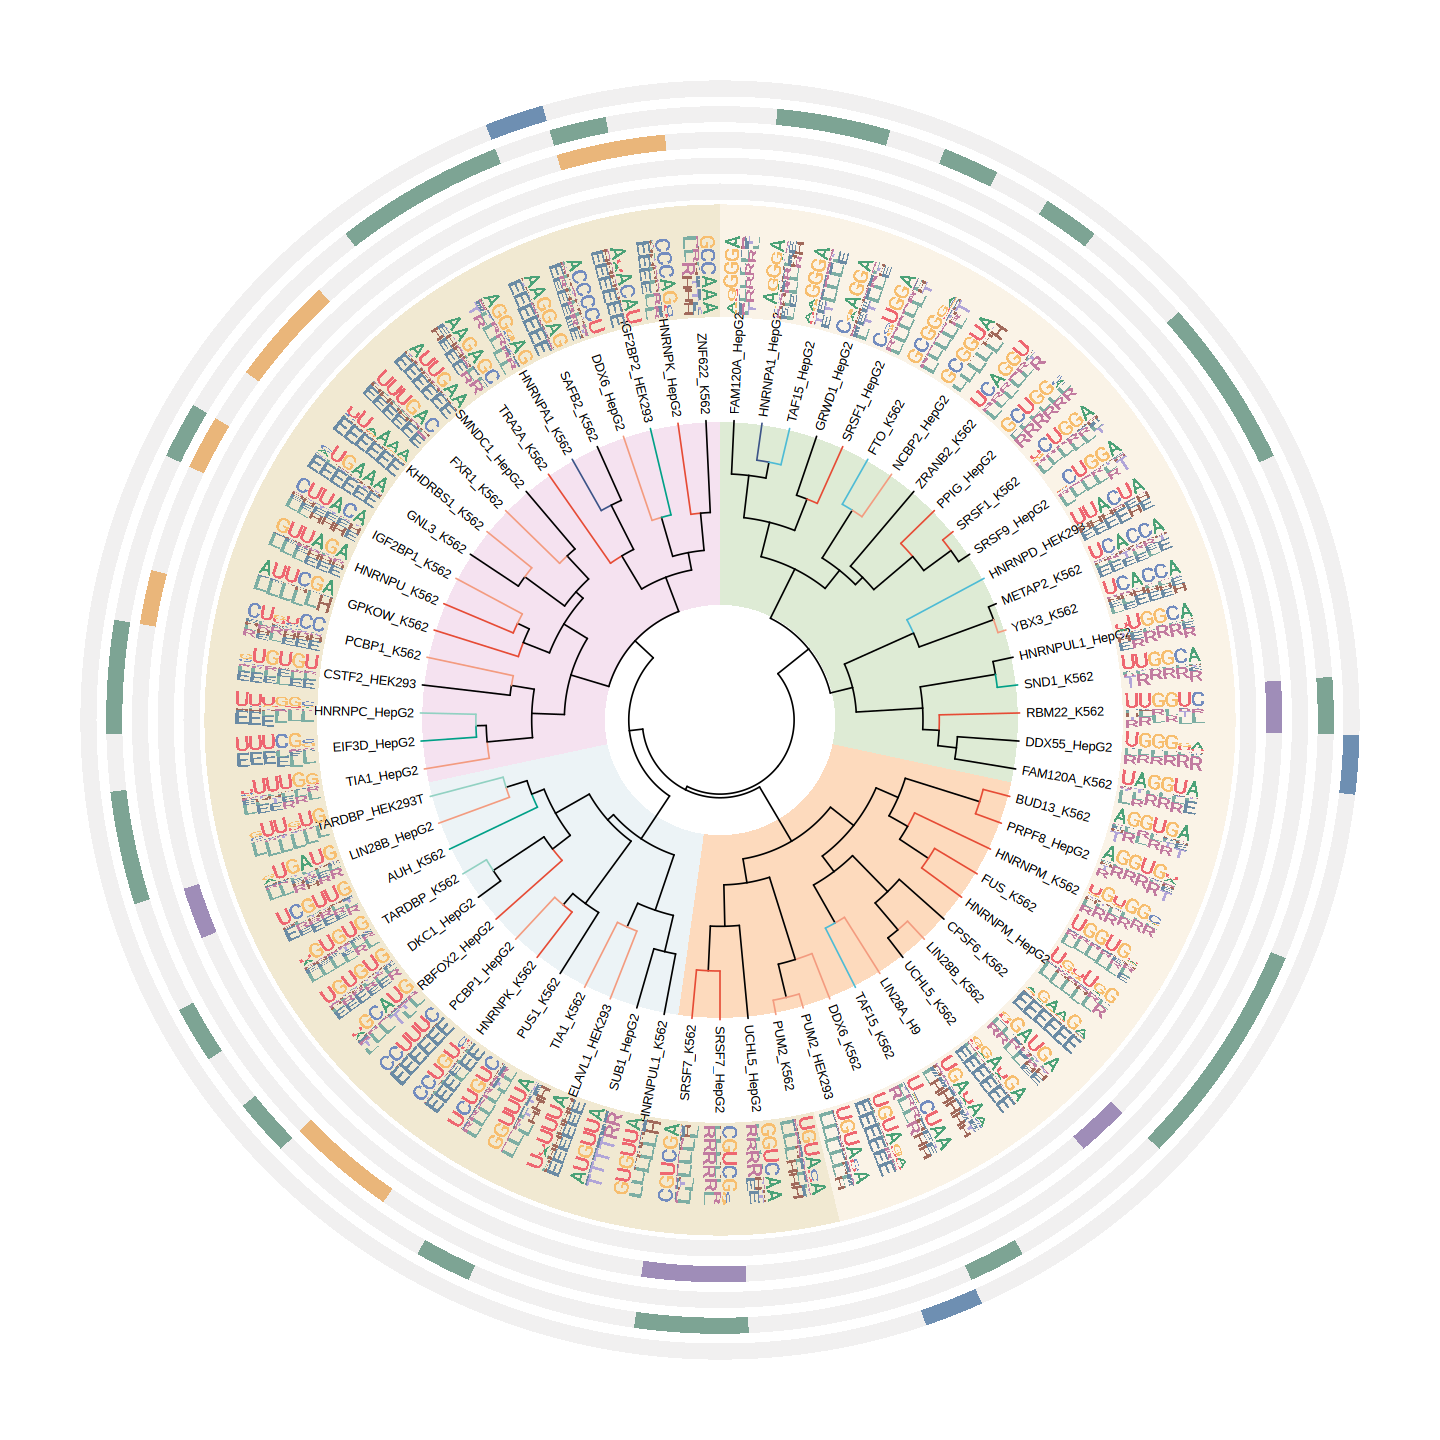

In [ ]:
library(dendsort)
library(dendextend)
library(circlize) # >= 0.4.10
library(ComplexHeatmap)
library(grid)
library(ggplot2)
library(ggseqlogo)
library(ggsci)
library(gridExtra)

setwd("/home/wangyubo/code/BRIDGE/docs/tutorials/notebooks/motif_analysis/")

#----------------------------------------------------------
# Utility functions for coordinate and angle conversion
#----------------------------------------------------------
radian = function(degree) {
  return(degree / 180 * pi)
}

polar2Cartesian = function(d) {
  # Converts polar coordinates to Cartesian coordinates
  # d: A matrix or data frame with two columns, where the first column is the angle in degrees
  #    and the second column is the radius (distance from origin)
  # Adjusts the radius by subtracting 0.5858 before conversion
  # Returns a matrix with x and y coordinates
  theta = radian(d[, 1])
  rou = d[, 2] - 0.5858
  x = rou * cos(theta)
  y = rou * sin(theta)
  return(cbind(x, y))
}

#----------------------------------------------------------
# Function to read motif files and parse PWM matrices
# Each motif contains 13 lines: 1 line for the motif name
# followed by 11 lines of numeric PWM values.
#----------------------------------------------------------
read_motifs <- function(file_path) {
  # Reads a file containing motif information and returns a list of motifs
  # Each motif is represented as a PWM matrix
  lines <- readLines(file_path)
  group_size <- 13
  motifs <- list()
   
  for (i in seq(1, length(lines), by = group_size)) {
    # Iterates through each motif group in the file
    motif_name <- lines[i]
    pwm_matrix <- matrix(NA, nrow = 11, ncol = 6)
     
    for (j in 1:11) {
      # Fills the PWM matrix with numeric values from the file lines
      pwm_matrix[j, ] <- as.numeric(strsplit(lines[i + j], "\\s+")[[1]])
    }
     
    motifs[[motif_name]] <- pwm_matrix
    # Stores the PWM matrix in a list with the motif name as the key
  }
   
  return(motifs)
  # Returns the list of motifs
}
#----------------------------------------------------------
# Load all motif data
#----------------------------------------------------------
all_motif_dir <- "../../../../motif_construction/datasets/Seq_struct_motif/"
all_motif_list <- list.files(all_motif_dir)
all_data_list <- list()

for (file in all_motif_list) {
  file_path <- file.path(all_motif_dir, file)
  motif_list <- read_motifs(file_path)
  all_data_list <- c(all_data_list, motif_list)
}

#----------------------------------------------------------
# Select motifs that are to be included in the Circos plot
#----------------------------------------------------------
selected_motif <- list.files("../../../../motif_construction/datasets/Seq_struct_motif_logos/")
selected_motif <- lapply(selected_motif, function(x) sub("\\.pdf$", "", x))
selected_motif_data <- all_data_list[unlist(selected_motif)]
selected_motif_name <- names(selected_motif_data)

# Flatten each motif matrix into a vector for clustering
flattened_matrix <- do.call(rbind, lapply(selected_motif_data, as.vector))
rownames(flattened_matrix) <- selected_motif_name

#----------------------------------------------------------
# Perform hierarchical clustering on motifs
#----------------------------------------------------------
hc <- hclust(dist(flattened_matrix), method = "ward.D2")
dend <- as.dendrogram(hc)

labels <- hc$labels[hc$order]
n <- length(labels)
max_height <- attr(dend, "height")
row_order <- hc$order
ordered_names <- rownames(flattened_matrix)[row_order]

#----------------------------------------------------------
# Initialize Circos plot and define annotation categories
#----------------------------------------------------------
# pdf("circos_plot.pdf", width = 12, height = 12)
options(repr.plot.width = 12, repr.plot.height = 12)
circos.clear()

circos.par(cell.padding = c(0, 0, 0, 0), start.degree = 90, gap.degree = 0, clock.wise = TRUE)
circos.initialize(sectors = "all", xlim = c(0, n))
# Motif_Construction_ROOT="../../../../motif_construction"
# motif_file_dir <- file.path(Motif_Construction_ROOT, "RBP_annotation_data/")

annot_dir <- "../../../../motif_construction/RBP_annotation_data"
DS_rbp <- readLines(file.path(annot_dir, "DSrbp_list.txt"))
KH_rbp <- readLines(file.path(annot_dir, "KHrbp_list.txt"))
RRM_rbp <- readLines(file.path(annot_dir, "RRMrbp_list.txt"))
ZNF_rbp <- readLines(file.path(annot_dir, "ZNFrbp_list.txt"))
Helicase_rbp <- readLines(file.path(annot_dir, "Helicase_list.txt"))
splice_rbp <- readLines(file.path(annot_dir, "splicerbp_list.txt"))
stability_rbp <- readLines(file.path(annot_dir, "stabilityrbp_list.txt"))
translation_rbp <- readLines(file.path(annot_dir, "translationrbp_list.txt"))

#----------------------------------------------------------
# Draw functional domain annotation tracks
# Each track corresponds to a specific RBP family
#----------------------------------------------------------
domain_tracks <- list(
  list(rbps = Helicase_rbp, color = "#6e8fb2", height = 0.025),
  list(rbps = RRM_rbp, color = "#7da494", height = 0.025),
  list(rbps = KH_rbp, color = "#eab67a", height = 0.025),
  list(rbps = ZNF_rbp, color = "#9f8db8", height = 0.025),
  list(rbps = DS_rbp, color = "#c16e71", height = 0.025)
)

for (track in domain_tracks) {
  circos.trackPlotRegion(
    ylim = c(0, 1), bg.border = NA, track.height = track$height, 
    track.margin = c(0.0075, 0.0075),
    panel.fun = function(x, y) {
      circos.rect(0, 0, n, 1, col = "#F1F0F0", border = NA)
      for (i in seq_len(n)) {
        name <- labels[[i]]
        rbp <- sub("#.*$", "", name)
        if (rbp %in% track$rbps) {
          circos.rect(i-1, 0, i, 1, col = track$color, border = NA)
        }
      }
    }
  )
}

#----------------------------------------------------------
# Background track for motif logos (sequence/structure)
#----------------------------------------------------------
circos.trackPlotRegion(ylim = c(-1, 1), bg.border = NA, track.height = 0.2, track.margin = c(0, 0),
                       panel.fun = function(x, y) {
                         circos.rect(0, -0.75, 98, 1, col = "#f1e9d2", border = NA)
                         circos.rect(98, -0.75, n, 1, col = "#FAF3E7", border = NA)
                       })

#----------------------------------------------------------
# Add RBP labels on the outermost ring
#----------------------------------------------------------
circos.trackPlotRegion(ylim = c(0, 1), bg.border = NA, track.height = 0.1, track.margin = c(0, 0.025),
                       panel.fun = function(x, y) {
                         for(i in seq_len(n)) {
                           circos.text(i-0.5, 0, labels[i],
                                       facing = "clockwise", niceFacing = TRUE, cex = 0.6,
                                       adj = c(0, 0.5))
                         }
                       })

#----------------------------------------------------------
# Function to colorize dendrogram branches based on RBP function
#----------------------------------------------------------
annot_color_list <- pal_npg()(7)

colorize_branches <- function(node, colors) {
  if (is.leaf(node)) {
    name <- attr(node, "label")
    rbp <- sub("#.*$", "", name)
    if (rbp %in% splice_rbp && rbp %in% stability_rbp && rbp %in% translation_rbp)
      color <- annot_color_list[7]
    else if (rbp %in% splice_rbp && rbp %in% stability_rbp)
      color <- annot_color_list[6]
    else if (rbp %in% translation_rbp && rbp %in% stability_rbp)
      color <- annot_color_list[5]
    else if (rbp %in% translation_rbp && rbp %in% splice_rbp)
      color <- annot_color_list[4]
    else if (rbp %in% translation_rbp)
      color <- annot_color_list[3]
    else if (rbp %in% stability_rbp)
      color <- annot_color_list[2]
    else if (rbp %in% splice_rbp)
      color <- annot_color_list[1]
    else
      color <- "#000000"
    attr(node, "edgePar") <- c(attr(node, "edgePar"), list(col = color))
  } else {
    attr(node, "edgePar") <- c(attr(node, "edgePar"), list(col = "black"))
    for (i in seq_len(length(node))) {
      node[[i]] <- colorize_branches(node[[i]], colors)
    }
  }
  return(node)
}

dend <- colorize_branches(dend)

#----------------------------------------------------------
# Add clustered dendrogram ring
#----------------------------------------------------------
cluster_groups <- cutree(hc, k = 4)
cluster_cls_color <- c("#ecf3f6", "#FDDABD", "#f5e2f0", "#deebd5", "#FC9A09")

circos.trackPlotRegion(ylim = c(0, max_height), bg.border = NA, track.height = 0.35,
                       panel.fun = function(x, y) {
                         for (i in seq_len(n)) {
                           circos.rect(i-1, 1.1, i, max_height-0.05, 
                                       col = cluster_cls_color[cluster_groups[labels[i]]], border = NA)
                         }
                         circos.dendrogram(dend, max_height = max_height, facing = "outside")
                       })

#----------------------------------------------------------
# Function to adjust structure matrix weights by power transformation
#----------------------------------------------------------
adjusted_str_matrix_power <- function(str, beta = 2) {
  adjusted_str <- matrix(0, nrow = nrow(str), ncol = ncol(str))
  
  for (col in seq_len(ncol(str))) {
    col_values <- str[, col]
    powered <- col_values^beta
    col_sum <- sum(powered)
    col_bits <- log2(col_sum)
    weights <- powered / col_sum
    adjusted_col <- weights * col_bits
    adjusted_str[, col] <- adjusted_col
  }
  
  return(abs(adjusted_str))
}

#----------------------------------------------------------
# Plot motif logos (sequence + structure) along the Circos tracks
#----------------------------------------------------------
for(i in seq_len(n)) {
  pwm_matrix <- selected_motif_data[[selected_motif_name[[row_order[i]]]]]
  seq <- pwm_matrix[1:4, ]
  rownames(seq) <- c("A", "C", "G", "U")
  
  str <- pwm_matrix[5:11, ]
  rownames(str) <- c("L", "R", "E", "H", "B", "M", "T")
  
  adjusted_height_matrix_str <- adjusted_str_matrix_power(str, beta = 6)
  rownames(adjusted_height_matrix_str) <- c("L", "R", "E", "H", "B", "M", "T")
  
  custom_col_scheme_seq <- make_col_scheme(
    chars = c("A", "C", "G", "U"),
    groups = c("A", "C", "G", "U"),
    cols = c("#4CA278", "#738CBF", "#F7BE6F", "#EE6771")
  )

  custom_col_scheme_str <- make_col_scheme(
    chars = c("L", "R", "E", "H", "B", "M", "T"),
    groups = c("L", "R", "E", "H", "B", "M", "T"),
    cols = c(
      "#7daea3", "#c27ba0", "#6b8ba4", "#a1695b", 
      "#a9b665", "#e0a96d", "#b1a5d8"
    )
  )
  
  adjusted_height_matrix_str <- -adjusted_height_matrix_str
  plot_seq <- ggseqlogo(seq, method = "bits", seq_type = "rna", col_scheme = custom_col_scheme_seq) + theme_void()
  plot_str <- ggseqlogo(adjusted_height_matrix_str, method = "custom", seq_type = "other", namespace = c("L", "R", "E", "H", "B", "M", "T"), col_scheme = custom_col_scheme_str) + theme_void()
  
  p_combined <- arrangeGrob(plot_seq, plot_str, ncol = 1, heights = c(1, 1.2))
  
  df1 = circlize(i-0.5, 0.3, track.index = 3)
  ang <- df1[, 1]
  degree <- ang %% 360
  if (degree > 90 & degree < 270) degree <- degree - 180
  df2 = polar2Cartesian(df1)
  x0 = df2[1, 1]
  y0 = df2[1, 2]

  pushViewport(viewport(
    x = x0 + 0.5,
    y = y0 + 0.5,
    width = 0.06,
    height = 0.025,
    angle = degree
  ))
  grid.draw(p_combined)
  popViewport()
}

# dev.off()
circos.clear()